# Entitiy Resolution PoC

Dieser PoC beschäftigt sich mit Entity Resolution (ER) mit Matryoshka Embeddings von `jina-embeddings-v4` und Hierarchical Navigable Small World (HNSW) für die ANN Suche als zu grunde liegende Technologien. Ziel ist die Maximierung der Konsistenz von oft unsauberen Daten.

Jina AI verwendet in ihren Modellen das Matryoshka Prinzip nach Kusupati et al. (2022). Hierbei werden verschiedene "Dimensionsstufen" in die Loss-Funktion eines Modells eingearbeitet:
$$
\mathcal{L}_{MRL}=∑_{m∈\mathcal{M}}c_m⋅\mathcal{L} ⁣(f^{(m)}(x), y)
$$

| Symbol | Bedeutung |
|--------|-----------|
| $\mathcal{M}$ | Menge der Nested-Dimensionen, z.B. $\{128, 256, 512, 1024, 2048\}$ |
| $m$ | Eine konkrete Dimension $m \in \mathcal{M}$ |
| $c_m$ | Gewicht für Dimension $m$ (oft $c_m = 1 \ \forall m$) |
| $f^{(m)}(x)$ | Erste $m$ Dimensionen des vollen Embeddings $f(x) \in \mathbb{R}^d$ |
| $\mathcal{L}$ | Basis-Loss (z.B. InfoNCE / Contrastive Loss) |

## Setup

In [14]:
import time
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from helper import setup_environment, setup_device, make_faiss_index, print_environment_info


in_kaggle = setup_environment()
DEVICE = setup_device()
print_environment_info(in_kaggle, DEVICE)

Installiere transformers==4.57.6...
Python:       /Users/finnhertsch/projects/entity-res/.venv/bin/python
transformers: 4.57.6
Environment : Local
Device      : mps


## Synthetische Datenerstellung

In [15]:
from DataProvider import SAPMasterDataGenerator
from IPython.display import display

generator = SAPMasterDataGenerator(42)

def generate_data(n):
    
    df_base = generator.generate_base_data(n=n)
    df_noisy = generator.generate_noisy_duplicates(df_base)
    print(f"Generated: {len(df_base)} originals, {len(df_noisy)} noisy duplicates.")
    return df_base, df_noisy


def highlight_differences(df_base, df_noisy, n_samples=10):
    base_sample = df_base.head(n_samples).reset_index(drop=True)
    noisy_sample = df_noisy.head(n_samples).reset_index(drop=True)

    shared_cols = [c for c in base_sample.columns if c in noisy_sample.columns]
    diff_mask = base_sample[shared_cols] != noisy_sample[shared_cols]

    def style_base(row):
        return ["background-color: #d4edda; color: #155724"] * len(row)

    def style_noisy(data):
        styles = pd.DataFrame("", index=data.index, columns=data.columns)
        for col in diff_mask.columns:
            if col in data.columns:
                styles.loc[diff_mask[col], col] = "background-color: #f8d7da; color: #721c24; font-weight: bold"
        return styles

    styled_base = (
        base_sample[shared_cols]
        .style.apply(style_base, axis=1)
        .set_caption("Base Records")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    )

    styled_noisy = (
        noisy_sample[shared_cols]
        .style.apply(style_noisy, axis=None)
        .set_caption("Noisy Duplicates  (red = changed field)")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    )

    display(styled_base)
    display(styled_noisy)
    return diff_mask


def show_diff_summary(diff_mask):
    summary = diff_mask.sum().rename("Changed Fields").to_frame()
    summary["Change Rate"] = (diff_mask.mean() * 100).round(1).astype(str) + "%"
    summary = summary[summary["Changed Fields"] > 0].sort_values("Changed Fields", ascending=False)

    display(
        summary.style
        .background_gradient(subset=["Changed Fields"], cmap="Reds")
        .set_caption("📊 Diff Summary (first 10 pairs)")
    )


def show_side_by_side_pair(df_base, df_noisy, idx=0):
    shared_cols = [c for c in df_base.columns if c in df_noisy.columns]
    row_base = df_base.iloc[idx][shared_cols]
    row_noisy = df_noisy.iloc[idx][shared_cols]

    comparison = pd.DataFrame({"Base": row_base, "Noisy": row_noisy})
    comparison["Changed"] = comparison["Base"] != comparison["Noisy"]

    display(
        comparison.style
        .apply(lambda row: [
            "", "",
            "color: red; font-weight: bold" if row["Changed"] else "color: green"
        ], axis=1)
        .set_caption(f"Record pair at index {idx}")
    )


df_base, df_noisy = generate_data(n=1_000)
diff_mask = highlight_differences(df_base, df_noisy, n_samples=10)
show_diff_summary(diff_mask)
show_side_by_side_pair(df_base, df_noisy, idx=0)

Generated: 1000 originals, 1000 noisy duplicates.


,text
0,"Dowerg | Henschelplatz 218, Backnang | Industrie-Zentrifuge"
1,"Davids AG & Co. OHG | Camilla-Gumprich-Allee 4-8, Altötting | OsciJet Fluidik-Oszillator"
2,"Thanel GmbH & Co. KG | Försterplatz 71/21, Ilmenau | OsciJet Fluidik-Oszillator"
3,"Hettner | Reisinggasse 2-9, Sebnitz | Industrie-Zentrifuge"
4,"Klotz | Bartholomäus-Speer-Platz 2/4, Konstanz | Laborabzug Pro X"
5,"Metz Schuster GmbH | Klappplatz 2/3, Eberswalde | Abfüllanlage Type 3"
6,"Kramer Hiller KGaA | Wilmsenallee 3, Herford | Abfüllanlage Type 3"
7,"Heuser Bolzmann AG & Co. OHG | Gerdi-Ortmann-Straße 32-44, Wolfratshausen | Abfüllanlage Type 3"
8,"Lorch | Hartmannplatz 21-30, Tecklenburg | Industrie-Zentrifuge"
9,"Schenk Bolnbach GmbH | Rädelring 1, Sondershausen | OsciJet Fluidik-Oszillator"


,text
0,"Dowerg | Henschelplatz 28, Backnanng"
1,"Davids AG&Co.OHG | Camilla-Gumprich-al. 8-4, Altötting | oSCIjET fLUIDIK-oSZILLATOR"
2,"Thanel Ges.m.b.H & Co. KG | FörsterPl. 17/21, Ilmenau | OsciJet Fluidik-Oszillator"
3,"Hetnner | Reisinggasse 2-9, Sebnitz | Industrie-Zentrifuge"
4,Kolzt | Laborabzug Pro X
5,Metz Schuster GmbH | Abfüllanlage Type 3
6,"Wilmsenallee 3, Herford | Abfüllange Type 3"
7,Heuser Bolzmann AG & Co. OHG | Abfüllanlage Tyype3
8,"Lorch | HartmannPl. 20-31, Tecklenburg | iNDUSTRIE-zENTRIFUGE"
9,"Schenk Bolnbach Gesellschaft mbH | Rädelrng. 1, Sondershausen | oSCIjET fLUIDIK-oSZILLATOR"


,Changed Fields,Change Rate
text,10,100.0%


,Base,Noisy,Changed
text,"Dowerg | Henschelplatz 218, Backnang | Industrie-Zentrifuge","Dowerg | Henschelplatz 28, Backnanng",True


## Erstellung der Embeddings

In [16]:
import hashlib
from pathlib import Path
from tqdm.auto import tqdm
from EmbeddingPipe import pipeline

CACHE_DIR = Path(".embedding_cache")
CACHE_DIR.mkdir(exist_ok=True)

OPTIMAL_BATCH_SIZE = {
    "cuda": 512,
    "mps":  256,
    "cpu":  64,
}

def _cache_key(texts: list[str], dtype: str) -> str:
    content = "".join(texts) + dtype
    return hashlib.md5(content.encode()).hexdigest()


def encode_with_cache(texts: list[str], label: str, dtype=np.float16) -> np.ndarray:
    key = _cache_key(texts, dtype.__name__)
    cache_file = CACHE_DIR / f"{label}_{key}.npy"

    if cache_file.exists():
        print(f"[{label}] Loading from cache...", end=" ")
        result = np.load(cache_file)
        print("done.")
        return result

    batch_size = OPTIMAL_BATCH_SIZE.get(DEVICE.type, 64)
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc=f"[{label}]", leave=False):
        batch = texts[i : i + batch_size]
        emb = pipeline.encode(batch, batch_size=len(batch))
        all_embeddings.append(emb.astype(dtype))

    result = np.vstack(all_embeddings)
    np.save(cache_file, result)
    print(f"[{label}] Cached → {cache_file}")
    return result


def encode_parallel(df_base, df_noisy) -> tuple[np.ndarray, np.ndarray]:
    base_emb  = encode_with_cache(df_base["text"].tolist(),  "base")
    noisy_emb = encode_with_cache(df_noisy["text"].tolist(), "noisy")
    return base_emb, noisy_emb


def print_embedding_stats(base_emb, noisy_emb):
    for label, emb in [("Base", base_emb), ("Noisy", noisy_emb)]:
        print(f"{label:6s} | shape: {emb.shape} | dtype: {emb.dtype} | {emb.nbytes / 1_000_000:.1f} MB")


base_embeddings_2048, noisy_embeddings_2048 = encode_parallel(df_base, df_noisy)
print_embedding_stats(base_embeddings_2048, noisy_embeddings_2048)

[base] Loading from cache... done.
[noisy] Loading from cache... done.
Base   | shape: (1000, 2048) | dtype: float16 | 4.1 MB
Noisy  | shape: (1000, 2048) | dtype: float16 | 4.1 MB


## Indizierung & Evaluation

In [17]:
from EmbeddingPipe import truncate_and_normalize

K = 5
N_RUNS = 100

def _measure_latency(index, noisy_emb: np.ndarray, n_runs: int) -> float:
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        index.search(noisy_emb, K)
        times.append((time.perf_counter() - start) * 1000 / len(noisy_emb))
    return float(np.median(times))

def evaluate_dimension(dim, index, base_emb_full, noisy_emb_full, ground_truth_ids) -> dict:
    print(f"Evaluating dimension: {dim}")

    base_emb  = truncate_and_normalize(base_emb_full,  dim).astype(np.float32)
    noisy_emb = truncate_and_normalize(noisy_emb_full, dim).astype(np.float32)

    
    index.add(base_emb)

    latency_ms = _measure_latency(index, noisy_emb, N_RUNS)
    _, indices  = index.search(noisy_emb, K)

    recall_at_1 = float(np.mean([gt == idx[0]  for gt, idx in zip(ground_truth_ids, indices)]))
    recall_at_5 = float(np.mean([gt in idx      for gt, idx in zip(ground_truth_ids, indices)]))

    base_full_norm  = truncate_and_normalize(base_emb_full,  2048).astype(np.float32)
    noisy_full_norm = truncate_and_normalize(noisy_emb_full, 2048).astype(np.float32)
    sims_full  = np.sum(base_full_norm  * noisy_full_norm,  axis=1)
    sims_trunc = np.sum(base_emb        * noisy_emb,        axis=1)
    info_retention, _ = pearsonr(sims_full, sims_trunc)

    return {
        "Dimension":              dim,
        "Recall@1":               recall_at_1,
        "Recall@5":               recall_at_5,
        "Latency (ms)":           round(latency_ms, 4),
        "Info Retention (Corr)":  round(float(info_retention), 6),
    }

## Visualisierung & Reporting

In [18]:
def plot_results(results_df):
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

    dims = results_df["Dimension"].astype(str)
    x = np.arange(len(dims))

    ax1.plot(results_df["Dimension"], results_df["Info Retention (Corr)"],
             marker='o', color='steelblue', linewidth=2)
    ax1.set_xscale('log')
    ax1.set_xticks(results_df["Dimension"])
    ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax1.set_title("Info Retention")
    ax1.set_xlabel("Dimension")
    ax1.set_ylabel("Correlation with 2048d")
    ax1.set_ylim(0.95, 1.01)

    ax2.bar(x, results_df["Recall@1"], color='#2ca02c', alpha=0.85, label='Recall@1')
    ax2.bar(x, results_df["Recall@5"], color="#0b3802", alpha=0.5, label='Recall@5')
    ax2.set_xticks(x)
    ax2.set_xticklabels(dims)
    ax2.set_title("Recall")
    ax2.set_xlabel("Dimension")
    ax2.set_ylabel("Score")
    ax2.set_ylim(0, 1.15)
    ax2.legend()

    ax3.bar(x, results_df["Latency (ms)"], color='#d62728', alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(dims)
    ax3.set_title("Search Latency")
    ax3.set_xlabel("Dimension")
    ax3.set_ylabel("ms / query")

    plt.suptitle("Dimension Evaluation", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## Ausführung

Index ist bereits gefüllt. Überspringe...
Evaluating dimension: 128
Evaluating dimension: 512
Evaluating dimension: 2048

--- Evaluationsergebnisse ---
 Dimension  Recall@1  Recall@5  Latency (ms)  Info Retention (Corr)
       128     0.925     0.957        0.0149               0.983692
       512     0.947     0.971        0.0240               0.994062
      2048     0.960     0.980        0.0598               1.000000


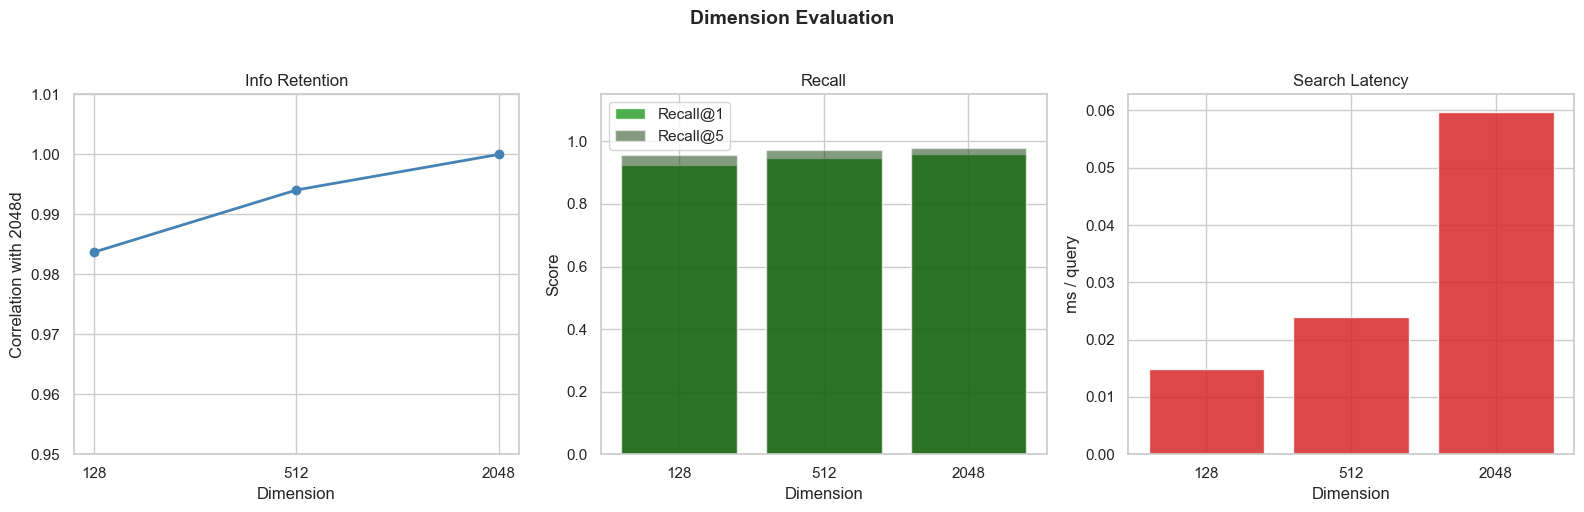

In [19]:
from FAISSIndex import Faiss128Singleton

dimensions = [128, 512, 2048]
results = []


base_emb_128 = truncate_and_normalize(base_embeddings_2048, 128).astype('float32')
noisy_emb_128 = truncate_and_normalize(noisy_embeddings_2048, 128).astype('float32')

global_index = Faiss128Singleton()
global_index.populate(base_emb_128)

for dim in dimensions:
    index = make_faiss_index(dim, DEVICE)
    res = evaluate_dimension(
        dim=dim,
        index=index,
        base_emb_full=base_embeddings_2048,
        noisy_emb_full=noisy_embeddings_2048,
        ground_truth_ids=df_noisy['ground_truth_id'].tolist()
    )
    results.append(res)
        
results_df = pd.DataFrame(results)
print("\n--- Evaluationsergebnisse ---")
print(results_df.to_string(index=False))

plot_results(results_df)

## Vorbereitung für die Entity Resolution

In [20]:
def get_candidates_for_noisy_data(noisy_embeddings, k=5):
    idx_manager = Faiss128Singleton()
    distances, indices = idx_manager.search(noisy_embeddings, k=k)
    return distances, indices

D, I = get_candidates_for_noisy_data(noisy_emb_128, 5)
print("Top 5 Nachbarn für das erste Noisy-Element:", I[0])

candidate_pairs = []
for i, neighbors in enumerate(I):
    for neighbor_idx in neighbors:
        candidate_pairs.append((df_noisy.iloc[i], df_base.iloc[neighbor_idx]))
print(len(candidate_pairs))

Top 5 Nachbarn für das erste Noisy-Element: [  0 236 695 911 101]
5000


## Feature Engineering

In [21]:
import re
from rapidfuzz import fuzz


def get_feature_vector(pair, distance_score):
    row_noisy, row_base = pair

    # 1. String similarities (0-100)
    name_sim = fuzz.token_sort_ratio(row_noisy['text'], row_base['text']) / 100.0

    # 2. Numeric check using regex (extract house numbers / postal codes)
    numbers_noisy = set(re.findall(r'\d+', row_noisy['text']))
    numbers_base = set(re.findall(r'\d+', row_base['text']))

    num_match = 1.0 if (numbers_noisy & numbers_base) else 0.0

    # 3. Vector score from FAISS retrieval
    vec_score = distance_score

    return [name_sim, num_match, vec_score]


features = []
labels = []

for i, neighbors in enumerate(I):
    for j, neighbor_idx in enumerate(neighbors):
        pair = (df_noisy.iloc[i], df_base.iloc[neighbor_idx])

        f_vec = get_feature_vector(pair, D[i][j])
        features.append(f_vec)

        is_match = 1 if df_noisy.iloc[i]['ground_truth_id'] == df_base.iloc[neighbor_idx].name else 0
        labels.append(is_match)


example_index = 67
print(
    f"Feature Example: {features[example_index]}\n"
    "[Name Similarity, Number Match, Cosine Similarity]\n"
    f"Label: {labels[example_index]}"
)

Feature Example: [0.6049382716049383, 0.0, np.float32(0.15625535)]
[Name Similarity, Number Match, Cosine Similarity]
Label: 0


## RandomForest Clf

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

X = np.array(features)
y = np.array(labels)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=skf, scoring='f1')

print("--- Cross-validation results ---")
print(f"F1 scores: {cv_scores}")
print(f"Mean F1 score: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})\n")

rf.fit(X, y)

predictions = rf.predict(X)
confirmed_pairs = []

for idx, pred in enumerate(predictions):
    if pred == 1:
        id_noisy = df_noisy.iloc[idx // 5].name
        id_base = I[idx // 5][idx % 5]
        confirmed_pairs.append((f"noisy_{id_noisy}", f"base_{id_base}"))

print(f"Number of confirmed duplicate pairs: {len(confirmed_pairs)}")

--- Cross-validation results ---
F1 scores: [0.91666667 0.95811518 0.95744681 0.92592593 0.93370166]
Mean F1 score: 0.9384 (+/- 0.0167)

Number of confirmed duplicate pairs: 899


--- Classification Report ---
                precision    recall  f1-score   support

Keine Dublette       0.98      1.00      0.99      4043
      Dublette       0.98      0.92      0.95       957

      accuracy                           0.98      5000
     macro avg       0.98      0.96      0.97      5000
  weighted avg       0.98      0.98      0.98      5000



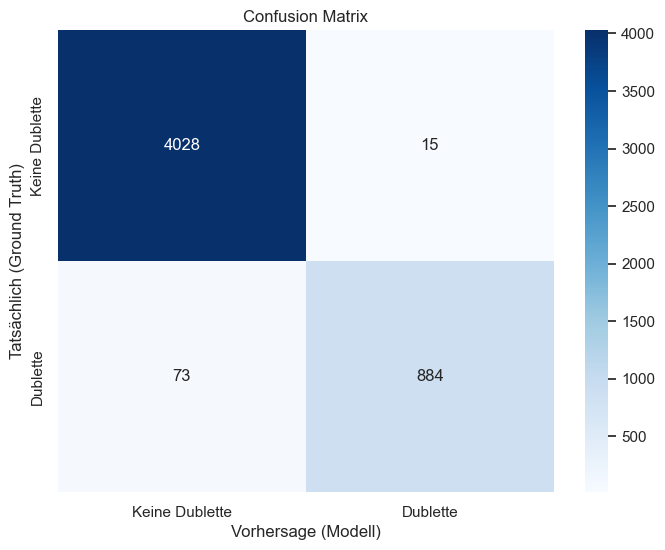

In [30]:
from sklearn.metrics import confusion_matrix, classification_report

print("--- Classification Report ---")
print(classification_report(labels, predictions, target_names=['Keine Dublette', 'Dublette']))

cm = confusion_matrix(labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Keine Dublette', 'Dublette'], 
            yticklabels=['Keine Dublette', 'Dublette'])
plt.xlabel('Vorhersage (Modell)')
plt.ylabel('Tatsächlich (Ground Truth)')
plt.title('Confusion Matrix')
plt.show()

## Clustering im Graph

In [24]:
import networkx as nx

G = nx.Graph()
G.add_edges_from(confirmed_pairs)

clusters = list(nx.connected_components(G))

print(f"Gefundene Cluster: {len(clusters)}")

Gefundene Cluster: 867


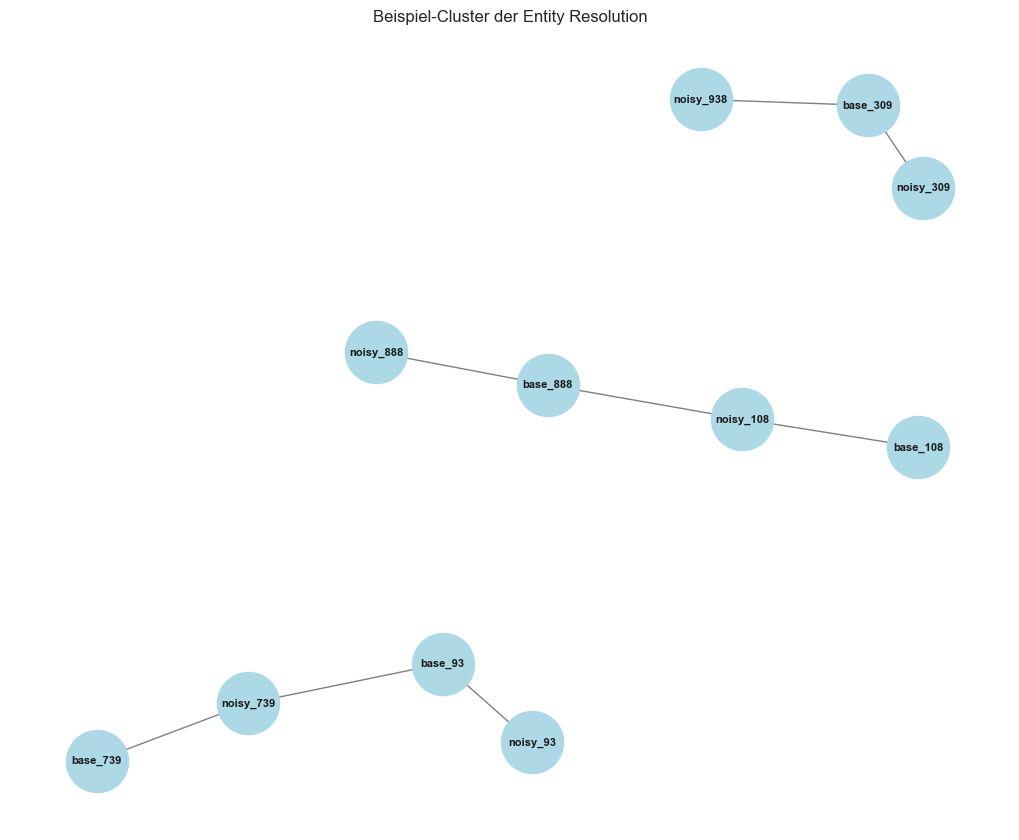

In [ ]:
interesting_clusters = [c for c in clusters if len(c) > 2][:3]

if not interesting_clusters:
    interesting_clusters = clusters[:5]

subgraph = G.subgraph([node for cluster in interesting_clusters for node in cluster])

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subgraph, k=0.5)

nx.draw(subgraph, pos, with_labels=True, 
        node_color='lightblue', edge_color='gray', 
        node_size=2000, font_size=8, font_weight='bold')

plt.title("Beispiel-Cluster der Entity Resolution")
plt.show()

## Merging

In [31]:
df_base_labeled = df_base.copy()
df_base_labeled.index = [f"base_{i}" for i in df_base_labeled.index]

df_noisy_labeled = df_noisy.copy()
df_noisy_labeled.index = [f"noisy_{i}" for i in df_noisy_labeled.index]

df_all = pd.concat([df_base_labeled, df_noisy_labeled])


def create_golden_records(clusters, df_all):
    golden_records = []

    for cluster in clusters:
        members = df_all.loc[list(cluster)]

        members['is_base'] = members.index.str.startswith('base')

        best_record = members.sort_values(
            by=['is_base', 'text'],
            key=lambda x: x.str.len() if x.name == 'text' else x,
            ascending=False
        ).iloc[0]

        record_dict = best_record.to_dict()
        record_dict['cluster_size'] = len(cluster)
        record_dict['merged_ids'] = ", ".join(list(cluster))

        golden_records.append(record_dict)

    return pd.DataFrame(golden_records)


df_golden = create_golden_records(clusters, df_all)

print(f"Original records: {len(df_all)}")
print(f"Golden records: {len(df_golden)}")
print("\n--- Example merge result ---")

example_cluster = [c for c in clusters if len(c) > 2][0]
print(f"Cluster members: {example_cluster}")
print("\nTexts in cluster:")

for m_id in example_cluster:
    print(f" - {m_id}: {df_all.loc[m_id, 'text']}")

example_golden = df_golden[
    df_golden['merged_ids'].str.contains(list(example_cluster)[0])
].iloc[0]

print(f"\n==> SELECTED GOLDEN RECORD: {example_golden['text']}")

Original records: 2000
Golden records: 867

--- Example merge result ---
Cluster members: {'noisy_739', 'base_739', 'base_93', 'noisy_93'}

Texts in cluster:
 - noisy_739: Reising GmbH &Co. KG | Reiner-Haering-Platz 3467, Rottweil | Abfüllanlage Type 3
 - base_739: Reising GmbH & Co. KG | Reiner-Haering-Platz 3467, Rottweil | Abfüllanlage Type 3
 - base_93: Jähn GmbH & Co. KGaA | Horst-Günter-Renner-Platz 8-6, Rottweil | Abfüllanlage Type 3
 - noisy_93: Jähn GmbH+Co.KGaA | Horst-Günter-Renner-pl. 6-8, Rottweil | Abfüllanlage Type 3

==> SELECTED GOLDEN RECORD: Jähn GmbH & Co. KGaA | Horst-Günter-Renner-Platz 8-6, Rottweil | Abfüllanlage Type 3


## Referenzen

Kusupati, A., Bhatt, G., Rege, A., Wallingford, M., Sinha, A., Ramanujan, V., … Farhadi, A. (2022). Matryoshka representation learning. Proceedings of the 36th International Conference on Neural Information Processing Systems. Presented at the New Orleans, LA, USA. Red Hook, NY, USA: Curran Associates Inc.

Günther, M., Sturua, S., Akram, M. K., Mohr, I., Ungureanu, A., Wang, B., … Xiao, H. (2025). jina-embeddings-v4: Universal Embeddings for Multimodal Multilingual Retrieval. arXiv [Cs.AI]. Retrieved from http://arxiv.org/abs/2506.18902